Original image shape: (396, 396, 3)
Number of pixels: 156816


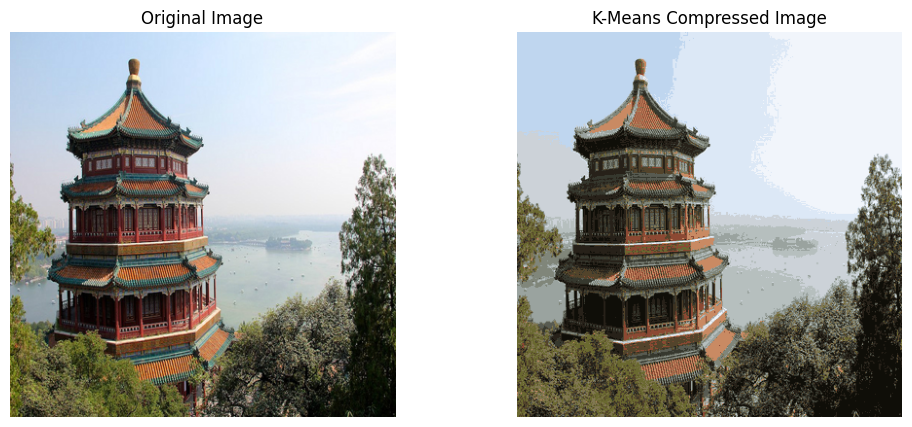

Original number of colours: 16,777,216
Compressed number of colours: 16
Image size: (396, 396, 3)


In [ ]:
# CH.SC.U4CSE24149
# VIGHRANTH SK
# MACHINE LEARNING - ACTIVITY 10
# K-MEANS CLUSTERING
# Exercise 2

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.datasets import load_sample_image
from sklearn.cluster import KMeans

# 1. Load and resize the image

image = load_sample_image("china.jpg")

image = Image.fromarray(image)
image = image.resize((396, 396))

image = np.array(image)

print("Original image shape:", image.shape)

# 2. Prepare the image data

pixels = image.reshape(-1, 3)

print("Number of pixels:", pixels.shape[0])

# 3. Apply K-Means clustering

k = 16

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

kmeans.fit(pixels)

# 4. Replace pixels with cluster center colours

compressed_pixels = kmeans.cluster_centers_[kmeans.labels_]

compressed_pixels = np.clip(
    compressed_pixels.astype(np.uint8),
    0,
    255
)

compressed_image = compressed_pixels.reshape(396, 396, 3)

# 5. Display the original and compressed images

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(compressed_image)
plt.title("K-Means Compressed Image")
plt.axis("off")

plt.show()

# 6. Display compression information

print("Original number of colours: 16,777,216")
print("Compressed number of colours:", k)
print("Image size:", compressed_image.shape)